## MSc Artificial Intelligence - Masters Project

## Farah Iqbal - S08431208

### Research Objective

The purpose of this notebook is to explore and prepare clinical data for the development of an explainable multimodal AI framework for Multiple Sclerosis desease prediction.

The clinical features explored will later be combined with MRI features and used within an Agentic AI decision-support framework.

## Notebook 1 Structure:

- Load the patient information spreadsheet
- Clean the column names
- Explore the EDSS scores
- Create a disease duration feature
- Create EDSS disability categories
- Check missing values
- Save a cleaned dataset for later modelling

## Import Libraries

In [ ]:
# Import libraries for data handling
import pandas as pd
import numpy as np

# Import libraries for visualisation
import matplotlib.pyplot as plt

# Import library for file handling in Google Colab
from google.colab import files

# Set pandas display options so columns are easier to view
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## Upload the Patient Data from Excel

The patient information file contains the clinical variables for the 60 Multiple Sclerosis patients.

This includes information such as age, gender, EDSS score, medication, presenting symptoms, co-morbidities and neurological examination findings.

## Upload File

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

file_path = "/content/drive/MyDrive/Supplementary Table 1 for patient info .xlsx"

raw_df = pd.read_excel(file_path, header=None)

Mounted at /content/drive


In [ ]:
from google.colab import files

uploaded = files.upload()

file_name = next(iter(uploaded))

Saving Supplementary Table 1 for patient info .xlsx to Supplementary Table 1 for patient info .xlsx


## Load Raw Data

In [ ]:
import pandas as pd

raw_df = pd.read_excel(file_name, header=None)

raw_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Does the patient has abnormality at the below ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ID,Gender,Age,Age of onset,EDSS,Does the time difference between MRI acquisiti...,Types of Medicines,Presenting Symptom,Dose the patient has Co-moroidity,Pyramidal,Cerebella,Brain stem,Sensory,Sphincters,Visual,Mental,Speech,Motor System,Sensory System,Coordination,Gait,Bowel and bladder function,Mobility,Mental State,Optic discs,Fields,Nystagmus,Ocular Movement,Swallowing
2,1,F,56,43,3,No,Gelenia,Motor,No,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,1,0,0
3,2,F,29,19,1.5,No,Gelenia,Sensory,No,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0
4,3,F,15,8,4,No,Tysabri,Motor,No,1,1,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0


## Adjust the Header Row

The spreadsheet has the actual column names stored in the first row rather than as proper dataframe headers.

This step uses the first row as the column names and removes it from the dataset.

In [ ]:
# Use the first row as the column names
new_columns = raw_df.iloc[0]

# Remove the first row from the dataframe
df = raw_df[1:].copy()

# Assign the correct column names
df.columns = new_columns

# Reset the index after removing the header row
df = df.reset_index(drop=True)

# Display the first few rows
df.head()

,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Does the patient has abnormality at the below neurological examination (1=Abnormal & 0=Normal),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,ID,Gender,Age,Age of onset,EDSS,Does the time difference between MRI acquisiti...,Types of Medicines,Presenting Symptom,Dose the patient has Co-moroidity,Pyramidal,Cerebella,Brain stem,Sensory,Sphincters,Visual,Mental,Speech,Motor System,Sensory System,Coordination,Gait,Bowel and bladder function,Mobility,Mental State,Optic discs,Fields,Nystagmus,Ocular Movement,Swallowing
1,1,F,56,43,3,No,Gelenia,Motor,No,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,1,0,0
2,2,F,29,19,1.5,No,Gelenia,Sensory,No,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0
3,3,F,15,8,4,No,Tysabri,Motor,No,1,1,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0
4,4,F,24,20,6,No,Tysabri,Sensory,No,1,1,1,0,1,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0


In [ ]:
# Look at the first 10 rows exactly as they exist in Excel

pd.set_option('display.max_columns', None)

raw_df.head(10)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Does the patient has abnormality at the below ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ID,Gender,Age,Age of onset,EDSS,Does the time difference between MRI acquisiti...,Types of Medicines,Presenting Symptom,Dose the patient has Co-moroidity,Pyramidal,Cerebella,Brain stem,Sensory,Sphincters,Visual,Mental,Speech,Motor System,Sensory System,Coordination,Gait,Bowel and bladder function,Mobility,Mental State,Optic discs,Fields,Nystagmus,Ocular Movement,Swallowing
2,1,F,56,43,3,No,Gelenia,Motor,No,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,1,0,0
3,2,F,29,19,1.5,No,Gelenia,Sensory,No,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0
4,3,F,15,8,4,No,Tysabri,Motor,No,1,1,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0
5,4,F,24,20,6,No,Tysabri,Sensory,No,1,1,1,0,1,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0
6,5,F,33,31,0,No,Avonex,Pain,No,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
7,6,F,44,40,5,No,Avonex,Motor,No,0,0,0,0,0,0,0,0,1,0,1,1,1,0,0,0,0,1,0,0
8,7,M,43,40,3.5,No,Betaferon,Motor & Visual,No,0,1,0,0,0,0,1,0,1,1,1,0,0,1,0,1,0,0,0,0
9,8,F,32,30,1,No,Gelenia,Visual,No,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Clean Column Names

In [ ]:
# The actual column names are stored in row 1

new_columns = raw_df.iloc[1]

# Data starts from row 2
df = raw_df[2:].copy()

# Assign correct column names
df.columns = new_columns

# Reset the index
df = df.reset_index(drop=True)

# Display first rows
df.head()

1,ID,Gender,Age,Age of onset,EDSS,Does the time difference between MRI acquisition and EDSS < two months,Types of Medicines,Presenting Symptom,Dose the patient has Co-moroidity,Pyramidal,Cerebella,Brain stem,Sensory,Sphincters,Visual,Mental,Speech,Motor System,Sensory System,Coordination,Gait,Bowel and bladder function,Mobility,Mental State,Optic discs,Fields,Nystagmus,Ocular Movement,Swallowing
0,1,F,56,43,3,No,Gelenia,Motor,No,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,1,0,0
1,2,F,29,19,1.5,No,Gelenia,Sensory,No,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0
2,3,F,15,8,4,No,Tysabri,Motor,No,1,1,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0
3,4,F,24,20,6,No,Tysabri,Sensory,No,1,1,1,0,1,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0
4,5,F,33,31,0,No,Avonex,Pain,No,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0


In [ ]:
df.columns

Index(['ID', 'Gender', 'Age', 'Age of onset', 'EDSS',
       'Does the time difference between MRI acquisition and EDSS < two months',
       'Types of Medicines', 'Presenting Symptom',
       ' Dose the patient has Co-moroidity', 'Pyramidal', 'Cerebella',
       'Brain stem', 'Sensory', 'Sphincters', 'Visual', 'Mental', 'Speech',
       'Motor System', 'Sensory System', 'Coordination', 'Gait',
       'Bowel and bladder function', 'Mobility', 'Mental State', 'Optic discs',
       'Fields', 'Nystagmus', 'Ocular Movement', 'Swallowing'],
      dtype='object', name=1)

In [ ]:
# Clean column names

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("-", "_")
    .str.replace("/", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)

# Display cleaned names
list(df.columns)

['ID',
 'Gender',
 'Age',
 'Age_of_onset',
 'EDSS',
 'Does_the_time_difference_between_MRI_acquisition_and_EDSS_<_two_months',
 'Types_of_Medicines',
 'Presenting_Symptom',
 'Dose_the_patient_has_Co_moroidity',
 'Pyramidal',
 'Cerebella',
 'Brain_stem',
 'Sensory',
 'Sphincters',
 'Visual',
 'Mental',
 'Speech',
 'Motor_System',
 'Sensory_System',
 'Coordination',
 'Gait',
 'Bowel_and_bladder_function',
 'Mobility',
 'Mental_State',
 'Optic_discs',
 'Fields',
 'Nystagmus',
 'Ocular_Movement',
 'Swallowing']

## Rename Long Columns

In [ ]:
# Rename long or unclear columns to simpler names

df = df.rename(columns={
    "Does_the_time_difference_between_MRI_acquisition_and_EDSS_<_two_months": "MRI_EDSS_Time_Difference_Under_2_Months",
    "Dose_the_patient_has_Co_moroidity": "Co_morbidity"
})

# Display updated column names
df.columns

Index(['ID', 'Gender', 'Age', 'Age_of_onset', 'EDSS',
       'MRI_EDSS_Time_Difference_Under_2_Months', 'Types_of_Medicines',
       'Presenting_Symptom', 'Co_morbidity', 'Pyramidal', 'Cerebella',
       'Brain_stem', 'Sensory', 'Sphincters', 'Visual', 'Mental', 'Speech',
       'Motor_System', 'Sensory_System', 'Coordination', 'Gait',
       'Bowel_and_bladder_function', 'Mobility', 'Mental_State', 'Optic_discs',
       'Fields', 'Nystagmus', 'Ocular_Movement', 'Swallowing'],
      dtype='object', name=1)

## Dataset Overview

This section checks the size of the dataset, column names and basic information about the variables.

## Dataset Shape and Info

In [ ]:
# Show number of rows and columns
print("Dataset shape:", df.shape)

# Display basic information about the dataset
df.info()

Dataset shape: (60, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 29 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   ID                                       60 non-null     object
 1   Gender                                   60 non-null     object
 2   Age                                      60 non-null     object
 3   Age_of_onset                             60 non-null     object
 4   EDSS                                     60 non-null     object
 5   MRI_EDSS_Time_Difference_Under_2_Months  60 non-null     object
 6   Types_of_Medicines                       60 non-null     object
 7   Presenting_Symptom                       60 non-null     object
 8   Co_morbidity                             60 non-null     object
 9   Pyramidal                                60 non-null     object
 10  Cerebella                               

## Preview Dataset

In [ ]:
# Display the first 10 rows
df.head(10)

1,ID,Gender,Age,Age_of_onset,EDSS,MRI_EDSS_Time_Difference_Under_2_Months,Types_of_Medicines,Presenting_Symptom,Co_morbidity,Pyramidal,Cerebella,Brain_stem,Sensory,Sphincters,Visual,Mental,Speech,Motor_System,Sensory_System,Coordination,Gait,Bowel_and_bladder_function,Mobility,Mental_State,Optic_discs,Fields,Nystagmus,Ocular_Movement,Swallowing
0,1,F,56,43,3,No,Gelenia,Motor,No,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,1,0,0
1,2,F,29,19,1.5,No,Gelenia,Sensory,No,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0
2,3,F,15,8,4,No,Tysabri,Motor,No,1,1,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0
3,4,F,24,20,6,No,Tysabri,Sensory,No,1,1,1,0,1,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0
4,5,F,33,31,0,No,Avonex,Pain,No,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
5,6,F,44,40,5,No,Avonex,Motor,No,0,0,0,0,0,0,0,0,1,0,1,1,1,0,0,0,0,1,0,0
6,7,M,43,40,3.5,No,Betaferon,Motor & Visual,No,0,1,0,0,0,0,1,0,1,1,1,0,0,1,0,1,0,0,0,0
7,8,F,32,30,1,No,Gelenia,Visual,No,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,9,F,36,33,6,No,Gelenia,Motore,No,1,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,1,0,0
9,10,F,39,35,3,No,Betaferon,Motor & Behavioural,No,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0


## Convert Important Numeric Columns

In [ ]:
# Convert key columns into numeric values, errors="coerce" converts invalid values into NaN

numeric_columns = ["ID", "Age", "Age_of_onset", "EDSS"]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Check the updated data types
df[numeric_columns].dtypes

,0
1,
ID,int64
Age,int64
Age_of_onset,int64
EDSS,float64


## Create Disease Duration Feature

Disease duration is a useful clinical biomarker in Multiple Sclerosis.

It can be calculated using: Disease Duration = Current Age - Age of Onset

## Create Disease Duration

In [ ]:
# Create a new feature for disease duration
df["Disease_Duration"] = df["Age"] - df["Age_of_onset"]

# Display key columns to check the calculation
df[["ID", "Age", "Age_of_onset", "Disease_Duration", "EDSS"]].head()

1,ID,Age,Age_of_onset,Disease_Duration,EDSS
0,1,56,43,13,3.0
1,2,29,19,10,1.5
2,3,15,8,7,4.0
3,4,24,20,4,6.0
4,5,33,31,2,0.0


## Explore EDSS Scores

EDSS is the main clinical disability score in Multiple Sclerosis.

In this project, EDSS will be used to create disability severity categories.

## EDSS Summary Statistics

In [ ]:
df["EDSS"].describe()

,EDSS
count,60.000000
mean,2.266667
std,1.595722
min,0.000000
25%,1.000000
50%,2.000000
75%,3.500000
max,6.000000


## EDSS Distribution Plot

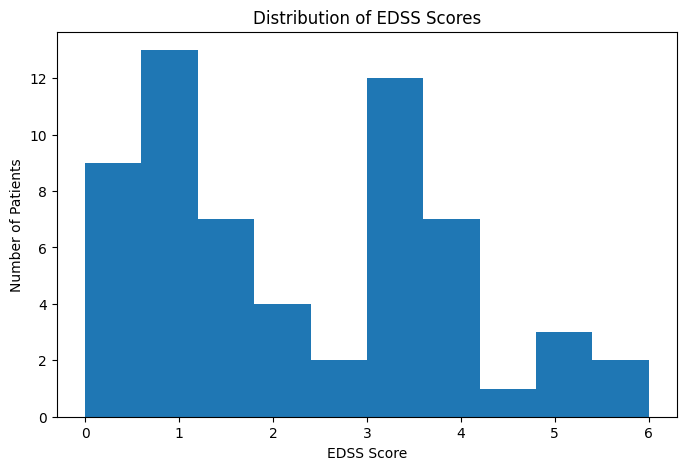

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["EDSS"].dropna(), bins=10)
plt.xlabel("EDSS Score")
plt.ylabel("Number of Patients")
plt.title("Distribution of EDSS Scores")
plt.show()

## Create EDSS Disability Categories

Because the dataset only contains 60 patients, predicting the exact EDSS score may be difficult.

A more realistic approach is to group EDSS into disability severity categories.

Categories:

- Low disability: EDSS 0.0 – 2.5
- Moderate disability: EDSS 3.0 – 5.5
- High disability: EDSS 6.0+

## Create EDSS Categories

In [ ]:
# Function to convert EDSS score into disability category

def create_edss_category(edss):
    # Check for missing value
    if pd.isna(edss):
        return np.nan

    # Low disability category
    elif edss <= 2.5:
        return "Low"

    # Moderate disability category
    elif edss <= 5.5:
        return "Moderate"

    # High disability category
    else:
        return "High"

# Apply the function to create a new target column
df["EDSS_Category"] = df["EDSS"].apply(create_edss_category)

# Display EDSS and category together
df[["ID", "EDSS", "EDSS_Category"]].head(10)

1,ID,EDSS,EDSS_Category
0,1,3.0,Moderate
1,2,1.5,Low
2,3,4.0,Moderate
3,4,6.0,High
4,5,0.0,Low
5,6,5.0,Moderate
6,7,3.5,Moderate
7,8,1.0,Low
8,9,6.0,High
9,10,3.0,Moderate


EDSS_Category
Low         35
Moderate    23
High         2
Name: count, dtype: int64


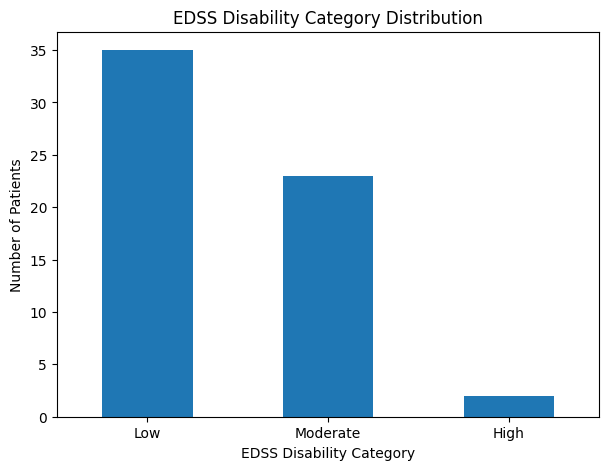

In [ ]:
pd.DataFrame(
    df["EDSS_Category"].value_counts()
).rename(columns={"EDSS_Category":"Count"})

# Count how many patients are in each EDSS category
category_counts = df["EDSS_Category"].value_counts()

# Display counts
print(category_counts)

# Plot category distribution
plt.figure(figsize=(7, 5))
category_counts.plot(kind="bar")
plt.xlabel("EDSS Disability Category")
plt.ylabel("Number of Patients")
plt.title("EDSS Disability Category Distribution")
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Create a summary table showing counts and percentages

edss_summary = pd.DataFrame({
    "Count": df["EDSS_Category"].value_counts(),
    "Percentage": round(
        df["EDSS_Category"].value_counts(normalize=True) * 100,
        2
    )
})

edss_summary

,Count,Percentage
EDSS_Category,,
Low,35,58.33
Moderate,23,38.33
High,2,3.33


## Check Class Balance

EDSS_Category
Low         35
Moderate    23
High         2
Name: count, dtype: int64


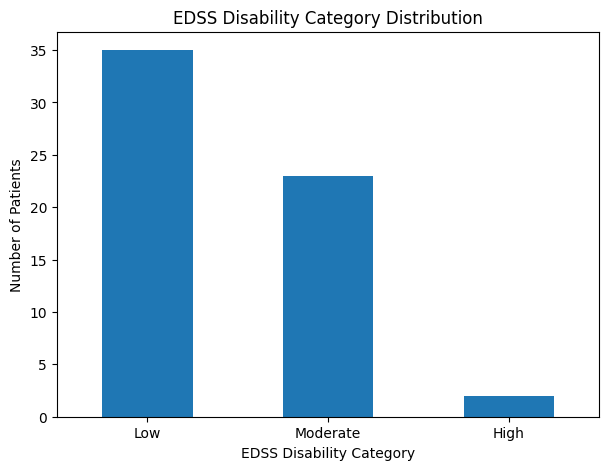

In [ ]:
# Count how many patients are in each EDSS category
category_counts = df["EDSS_Category"].value_counts()

# Display counts
print(category_counts)

# Plot category distribution
plt.figure(figsize=(7, 5))
category_counts.plot(kind="bar")
plt.xlabel("EDSS Disability Category")
plt.ylabel("Number of Patients")
plt.title("EDSS Disability Category Distribution")
plt.xticks(rotation=0)
plt.show()

## Check Missing Values

Missing values can affect model training, so this section checks which columns contain missing data.

## Missing Values

In [ ]:
# Count missing values in each column
missing_values = df.isnull().sum()

# Show only columns with missing values
missing_values[missing_values > 0]

,0
1,


## Explore Categorical Variables

This section checks the main categorical variables, including gender, medication type, presenting symptoms and co-morbidities.

## Categorical Variable Counts

In [ ]:
# List of important categorical variables
categorical_columns = [
    "Gender",
    "Types_of_Medicines",
    "Presenting_Symptom",
    "Co_morbidity",
    "MRI_EDSS_Time_Difference_Under_2_Months"
]

# Display value counts for each categorical variable
for col in categorical_columns:
    print("\n", "="*50)
    print(col)
    print("="*50)
    print(df[col].value_counts(dropna=False))


Gender
Gender
F    46
M    13
N     1
Name: count, dtype: int64

Types_of_Medicines
Types_of_Medicines
Betaferon    24
Rebif        14
Gelenia       9
Tysabri       8
Avonex        5
Name: count, dtype: int64

Presenting_Symptom
Presenting_Symptom
Sensory                                              19
Visual                                               14
Motor                                                10
Balance                                               4
Motor & Visual                                        2
Pain                                                  1
Motore                                                1
Motor & Behavioural                                   1
Sensory  & Visual                                     1
Visual & Balance                                      1
Balance &Motor                                        1
Sensory &Motor                                        1
Sensory & Motor                                       1
Sensory & Visual ,Balan

## Explore Neurological Examination Features

The dataset includes several neurological examination features coded as:

1 = Abnormal
0 = Normal

These features can be used as clinical biomarkers in the prediction model.

## Identify Neurological Columns

In [ ]:
# These are the neurological examination columns from the dataset
neuro_columns = [
    "Pyramidal",
    "Cerebella",
    "Brain_stem",
    "Sensory",
    "Sphincters",
    "Visual",
    "Mental",
    "Speech",
    "Motor_System",
    "Sensory_System",
    "Coordination",
    "Gait",
    "Bowel_and_bladder_function",
    "Mobility",
    "Mental_State",
    "Optic_discs",
    "Fields",
    "Nystagmus",
    "Ocular_Movement",
    "Swallowing"
]

# Convert neurological columns to numeric
for col in neuro_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Check how many abnormal findings each patient has
df["Total_Abnormal_Neuro_Findings"] = df[neuro_columns].sum(axis=1)

# Display results
df[["ID", "EDSS", "EDSS_Category", "Total_Abnormal_Neuro_Findings"]].head()

1,ID,EDSS,EDSS_Category,Total_Abnormal_Neuro_Findings
0,1,3.0,Moderate,4
1,2,1.5,Low,3
2,3,4.0,Moderate,6
3,4,6.0,High,7
4,5,0.0,Low,1


## Plot Abnormal Neurological Findings

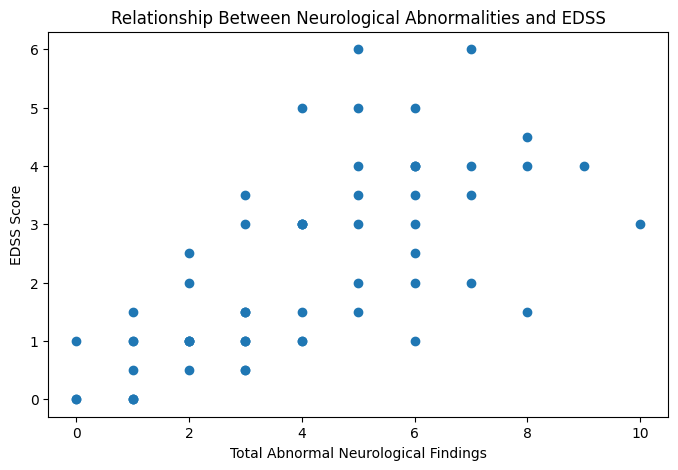

In [ ]:
# Plot total abnormal neurological findings against EDSS score

plt.figure(figsize=(8, 5))
plt.scatter(df["Total_Abnormal_Neuro_Findings"], df["EDSS"])
plt.xlabel("Total Abnormal Neurological Findings")
plt.ylabel("EDSS Score")
plt.title("Relationship Between Neurological Abnormalities and EDSS")
plt.show()

## Correlation Check

In [ ]:
# Select numeric columns for correlation analysis
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Calculate correlation with EDSS
edss_correlations = numeric_df.corr()["EDSS"].sort_values(ascending=False)

# Display correlations
edss_correlations

,EDSS
1,
EDSS,1.000000
Total_Abnormal_Neuro_Findings,0.674348
Coordination,0.443328
Pyramidal,0.426462
Motor_System,0.409482
Sphincters,0.371669
Gait,0.338144
Nystagmus,0.332474
Cerebella,0.326457


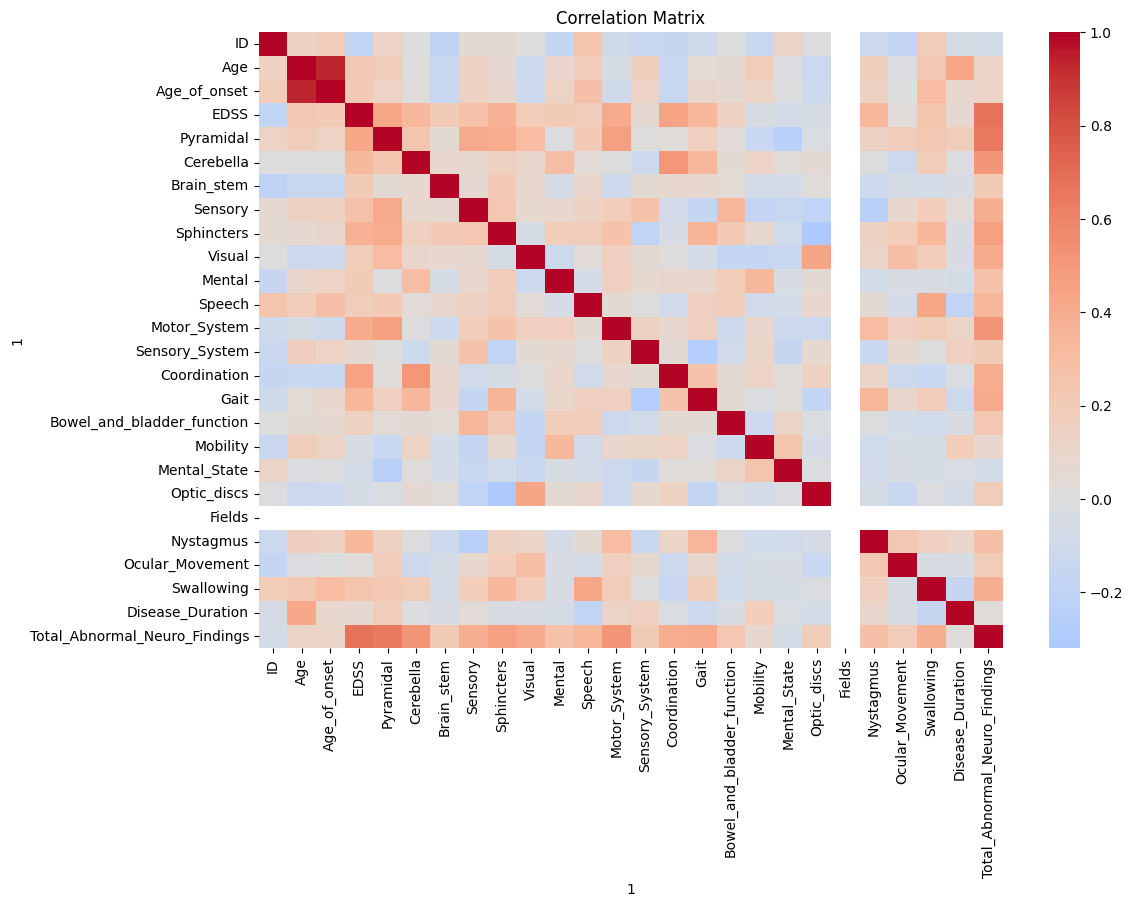

In [ ]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

## Prepare Clean Dataset for Modelling

This step selects the most useful columns for the first clinical model.

Later, MRI-derived features such as lesion volume will be added to this dataset.

## Select Useful Columns

In [ ]:
selected_columns = [
    "ID",
    "Gender",
    "Age",
    "Age_of_onset",
    "Disease_Duration",
    "MRI_EDSS_Time_Difference_Under_2_Months",
    "Types_of_Medicines",
    "Presenting_Symptom",
    "Co_morbidity",
    "Total_Abnormal_Neuro_Findings",
    "EDSS",
    "EDSS_Category"
] + neuro_columns

# Create a clean dataframe
clean_df = df[selected_columns].copy()

# Display the clean dataset
clean_df.head()

1,ID,Gender,Age,Age_of_onset,Disease_Duration,MRI_EDSS_Time_Difference_Under_2_Months,Types_of_Medicines,Presenting_Symptom,Co_morbidity,Total_Abnormal_Neuro_Findings,EDSS,EDSS_Category,Pyramidal,Cerebella,Brain_stem,Sensory,Sphincters,Visual,Mental,Speech,Motor_System,Sensory_System,Coordination,Gait,Bowel_and_bladder_function,Mobility,Mental_State,Optic_discs,Fields,Nystagmus,Ocular_Movement,Swallowing
0,1,F,56,43,13,No,Gelenia,Motor,No,4,3.0,Moderate,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,1,0,0
1,2,F,29,19,10,No,Gelenia,Sensory,No,3,1.5,Low,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0
2,3,F,15,8,7,No,Tysabri,Motor,No,6,4.0,Moderate,1,1,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0
3,4,F,24,20,4,No,Tysabri,Sensory,No,7,6.0,High,1,1,1,0,1,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0
4,5,F,33,31,2,No,Avonex,Pain,No,1,0.0,Low,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0


## Check Clean Dataset

In [ ]:
# Check shape of clean dataset
print("Clean dataset shape:", clean_df.shape)

# Check missing values in clean dataset
clean_df.isnull().sum()

Clean dataset shape: (60, 32)


,0
1,
ID,0
Gender,0
Age,0
Age_of_onset,0
Disease_Duration,0
MRI_EDSS_Time_Difference_Under_2_Months,0
Types_of_Medicines,0
Presenting_Symptom,0
Co_morbidity,0


## Save Clean Dataset

In [ ]:
# Save the cleaned dataset as a CSV file
clean_df.to_csv("clean_patient_data.csv", index=False)

print("Clean dataset saved as clean_patient_data.csv")

Clean dataset saved as clean_patient_data.csv


In [ ]:
# Download the cleaned CSV file to your computer
files.download("clean_patient_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Export Cleaned Clinical Dataset

The cleaned clinical dataset is exported for use in the next stage of the project, where it will be merged with MRI-derived biomarkers to create a multimodal dataset for disability severity prediction.

In [ ]:
# Create the output folder if it doesn't already exist
import os

output_folder = "/content/drive/MyDrive/MS_Dissertation/Outputs"
os.makedirs(output_folder, exist_ok=True)

# Export the cleaned clinical dataset
clinical_output_path = os.path.join(output_folder, "cleaned_clinical_data.csv")

df.to_csv(clinical_output_path, index=False)

print("Clinical dataset exported successfully.")
print(clinical_output_path)

Clinical dataset exported successfully.
/content/drive/MyDrive/MS_Dissertation/Outputs/cleaned_clinical_data.csv


## Summary

The cleaned dataset created here will be used as the clinical component of the project. In the next stage, MRI features such as lesion volume and lesion burden will be extracted and combined with the clinical data to create a multimodal dataset.

The aim is to use this combined information to develop a model capable of predicting disability severity in Multiple Sclerosis patients. Rather than focusing only on prediction accuracy, the project will also investigate how an Agentic AI approach can help explain the model's decisions in a way that is easier to understand and more meaningful from a clinical perspective.